# 📚 Exercise Session - Week 3: Attention, Tokenization, and Transformers
**Main Topics**: Attention, Tokenization, and Transformers for Sequence-to-Sequence Modeling

**Overview**

This week’s session dives into Transformers for sequence-to-sequence (Seq2Seq) tasks, with a special focus on machine translation and attention visualization. By the end, you will have built and trained a Transformer model capable of translating text from one language to another—and you’ll see how attention helps it learn alignments across tokens.

1. [**TASK A:** Transformer Implementation](#Task-A:-Transformer-Implementation)
- Build a BPE tokenizer
- Implement a Transformer encoder-decoder model using PyTorch

2. [**TASK B:** Train a Machine Translation Model](#Task-B:-Train-a-Machine-Translation-Model)
- Use Transformer from Task A to train a machine translation model
- Visualize the cross-attention weights

3. **Optional Extensions**
- Learning Rate Scheduler: Try adding a scheduler (like Warmup or ReduceLROnPlateau) to potentially improve convergence.
- Periodic Validation: Every `m` batches or at epoch’s end, evaluate on a validation set to track loss or metrics like BLEU.
- Use PyTorch `DataLoader`

**Tips & Hints**
- **Overfitting on a Single Example**: If your model cannot easily learn one sample to near-perfect accuracy, it often indicates an implementation bug or mismatch in shapes/masks.
- **Masking**: Pay careful attention to causal masks in the decoder, ensuring the model does not see future tokens.
- **Debugging**: Print shapes and partial outputs, or watch the attention scores to confirm they behave as expected.


> **By the end of the session you will be able to:**
> - ✅  Implement an encoder-decoder Transformer model using PyTorch
> - ✅  Train your model on a machine translation corpus
> - ✅  Understand attention mechanism within the Transformer architecture
> - ✅  Be more interested in NLP 😉

**Note**: This notebook is intended to be run with a GPU. If you do not have access to one, consider using [Google Colab](https://colab.research.google.com).

## Task A: Transformer Implementation

**Quick Reminder**
We will be implementing the following encoder-decoder transformer architecture following the original [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper!

![Transformer Architecture](transformer_arch.png)

In this part, you will implement an encoder-decoder Transformer model using [Pytorch](https://pytorch.org/)

In [ ]:
!pip install datasets
!pip install seaborn
!pip install tokenizers transformers torch

# Transformer Architecture

In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# For reproducibility
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0):
        super(MultiHeadAttention, self).__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = hidden_dim // num_heads

        # These layers transform the input embeddings to queries, keys, and values
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.key_proj   = nn.Linear(hidden_dim, hidden_dim)
        self.value_proj = nn.Linear(hidden_dim, hidden_dim)

        # Final projection after concatenating heads
        self.out_proj   = nn.Linear(hidden_dim, hidden_dim)

        # Dropout for attention weights
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        """
        Args:
            query, key, value: Tensors of shape [batch_size, seq_len, hidden_dim].
            mask: Optional tensor of shape [batch_size, 1, seq_len, seq_len] or
                  [batch_size, num_heads, seq_len, seq_len] to mask attention.

        Returns:
            output: [batch_size, seq_len, hidden_dim]
            attn_weights: [batch_size, num_heads, seq_len, seq_len]
        """
        batch_size = query.size(0)

        # 1) Linear projections of Q, K, V
        Q = self.query_proj(query)  # [batch_size, seq_len, hidden_dim]
        K = self.key_proj(key)      # [batch_size, seq_len, hidden_dim]
        V = self.value_proj(value)  # [batch_size, seq_len, hidden_dim]

        # 2) Reshape into [batch_size, num_heads, seq_len, head_dim]
        Q = Q.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)
        # Now Q, K, V each have shape [batch_size, num_heads, seq_len, head_dim]

        # 3) Scaled dot-product attention
        #    attention_scores = (Q @ K^T) / sqrt(head_dim)
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # attention_scores: [batch_size, num_heads, seq_len, seq_len]

        # Optional mask
        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, float('-inf'))

        # Softmax along the last dimension (seq_len of K)
        attn_weights = F.softmax(attention_scores, dim=-1)
        # Apply dropout to attention weights
        attn_weights = self.dropout(attn_weights)

        # Multiply by V
        # attention_output shape: [batch_size, num_heads, seq_len, head_dim]
        attention_output = torch.matmul(attn_weights, V)

        # 4) Concat heads: transpose back and then reshape
        # From [batch_size, num_heads, seq_len, head_dim] -> [batch_size, seq_len, hidden_dim]
        attention_output = attention_output.transpose(1, 2).contiguous()
        attention_output = attention_output.view(batch_size, -1, self.hidden_dim)

        # 5) Final linear projection
        output = self.out_proj(attention_output)

        return output, attn_weights


In [3]:
class EncoderLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads, intermediate_size, dropout=0):
        super(EncoderLayer, self).__init__()

        self.self_attn = MultiHeadAttention(hidden_dim, num_heads, dropout)
        self.linear1   = nn.Linear(hidden_dim, intermediate_size)
        self.linear2   = nn.Linear(intermediate_size, hidden_dim)
        self.norm1     = nn.LayerNorm(hidden_dim)
        self.norm2     = nn.LayerNorm(hidden_dim)
        self.dropout1  = nn.Dropout(dropout)
        self.dropout2  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # x shape: [batch_size, seq_len, hidden_dim]

        # 1) Multi-head self-attention
        attn_output, _ = self.self_attn(x, x, x, mask=mask)
        x = x + attn_output  # residual
        x = self.norm1(x)

        # 2) Feed-forward
        ff_output = self.linear2(F.relu(self.linear1(x)))
        x = x + ff_output  # residual
        x = self.norm2(x)

        return x

In [4]:
class DecoderLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads, intermediate_size, dropout=0):
        super(DecoderLayer, self).__init__()

        self.self_attn        = MultiHeadAttention(hidden_dim, num_heads, dropout)
        self.cross_attn       = MultiHeadAttention(hidden_dim, num_heads, dropout)

        self.linear1          = nn.Linear(hidden_dim, intermediate_size)
        self.linear2          = nn.Linear(intermediate_size, hidden_dim)

        self.norm1            = nn.LayerNorm(hidden_dim)
        self.norm2            = nn.LayerNorm(hidden_dim)
        self.norm3            = nn.LayerNorm(hidden_dim)


    def forward(self, x, enc_output, tgt_mask=None, cross_attn_mask=None):
        """
        x: [batch_size, tgt_seq_len, hidden_dim] (decoder input embeddings)
        enc_output: [batch_size, src_seq_len, hidden_dim] (encoder output)
        tgt_mask: mask for target self-attention
        cross_attn_mask: mask for encoder-decoder attention
        """
        # 1) Masked self-attention (decoder)
        attn_output, _ = self.self_attn(x, x, x, mask=tgt_mask)
        x = x + attn_output
        x = self.norm1(x)

        # 2) Cross-attention (encoder-decoder)
        cross_attn_output, attn_weights = self.cross_attn(x, enc_output, enc_output, mask=cross_attn_mask)
        x = x + cross_attn_output
        x = self.norm2(x)

        # 3) Feed-forward
        ff_output = self.linear2(F.relu(self.linear1(x)))
        x = x + ff_output
        x = self.norm3(x)

        return x, attn_weights

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, max_len=1024, dropout=0):
        super(Encoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.pos_encoding = nn.Embedding(max_len, hidden_dim)
        self.layers = nn.ModuleList([
            EncoderLayer(hidden_dim, num_heads, intermediate_size, dropout) for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        """
        src: [batch_size, src_seq_len]
        src_mask: (optional)
        """
        x = self.embedding(src) * math.sqrt(self.hidden_dim)
        x = x + self.pos_encoding(torch.arange(src.size(1)).to(src.device)).unsqueeze(0)

        for layer in self.layers:
            x = layer(x, mask=src_mask)

        return x  # shape: [batch_size, src_seq_len, hidden_dim]


class Decoder(nn.Module):
    def __init__(self, vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, max_len=1024, dropout=0):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.pos_encoding = nn.Embedding(max_len, hidden_dim)
        self.layers = nn.ModuleList([
            DecoderLayer(hidden_dim, num_heads, intermediate_size, dropout) for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, enc_output, tgt_mask=None, cross_attn_mask=None):
        """
        tgt: [batch_size, tgt_seq_len]
        enc_output: [batch_size, src_seq_len, hidden_dim]
        """
        x = self.embedding(tgt) * math.sqrt(self.hidden_dim)
        x = x + self.pos_encoding(torch.arange(tgt.size(1)).to(tgt.device)).unsqueeze(0)

        attn_weights = None
        for layer in self.layers:
            x, attn_weights = layer(x, enc_output, tgt_mask=tgt_mask, cross_attn_mask=cross_attn_mask)

        # Final projection to vocabulary
        logits = self.out_proj(x)  # [batch_size, tgt_seq_len, vocab_size]
        return logits, attn_weights

In [7]:
import torch

def build_causal_mask(seq_len, device=None):
    """
    Returns a 2D causal mask of shape [seq_len, seq_len],
    where True means 'allowed to attend' and False means 'disallowed'.
    """
    return torch.tril(torch.ones((seq_len, seq_len), dtype=torch.bool, device=device))

def expand_causal_mask(causal_2d, batch_size, num_heads):
    # causal_2d: shape [seq_len, seq_len]
    # expand to [batch_size, num_heads, seq_len, seq_len]
    causal_4d = causal_2d.unsqueeze(0).unsqueeze(0)  # => [1,1,seq_len,seq_len]
    causal_4d = causal_4d.expand(batch_size, num_heads, causal_2d.size(0), causal_2d.size(1))
    return causal_4d

def expand_padding_mask(pad_mask_2d, num_heads):
    # pad_mask_2d: shape [batch_size, seq_len], 1 = valid, 0 = pad
    # step 1) Convert to bool if needed
    pad_mask_bool = pad_mask_2d.bool()  # shape [batch_size, seq_len]
    # step 2) unsqueeze => [batch_size, 1, 1, seq_len]
    pad_mask_4d = pad_mask_bool.unsqueeze(1).unsqueeze(2)
    # step 3) broadcast across the query dimension
    batch_size, _, _, seq_len = pad_mask_4d.shape
    pad_mask_4d = pad_mask_4d.expand(batch_size, num_heads, seq_len, seq_len)
    return pad_mask_4d


def build_decoder_mask(
    pad_mask_2d: torch.Tensor,
    num_heads: int
):
    """
    Combine the target padding mask with the causal mask
    to produce a final decoder mask of shape:
    [batch_size, num_heads, seq_len, seq_len],
    where True means 'allowed', False means 'masked out'.
    """
    device = pad_mask_2d.device
    batch_size, seq_len = pad_mask_2d.shape

    # 1) Build the 2D causal mask
    causal_2d = build_causal_mask(seq_len, device=device)

    # 2) Expand to 4D
    causal_4d = expand_causal_mask(causal_2d, batch_size, num_heads)

    # 3) Expand the padding mask to 4D
    pad_4d = expand_padding_mask(pad_mask_2d, num_heads)

    # 4) Final mask = causal AND pad
    final_mask = causal_4d & pad_4d  # shape [batch_size, num_heads, seq_len, seq_len]
    return final_mask


In [8]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, hidden_dim=512, num_heads=8, intermediate_size=2048,
                 num_layers=6, dropout=0):
        super(Transformer, self).__init__()
        self.num_heads = num_heads
        self.encoder = Encoder(src_vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, dropout=dropout)
        self.decoder = Decoder(tgt_vocab_size, hidden_dim, num_heads, intermediate_size, num_layers, dropout=dropout)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, cross_attn_mask=None):

        if src_mask is not None:
            src_mask = src_mask[:, None, None, :]
            src_mask = src_mask.expand(-1, -1, src_mask.size(-1), -1)

        tgt_mask = build_decoder_mask(tgt_mask, num_heads=self.num_heads)

        enc_output = self.encoder(src, src_mask)
        logits, attn_weights = self.decoder(tgt, enc_output, tgt_mask, cross_attn_mask)
        return logits, attn_weights

## Task B: Train a Machine Translation Model
First, you need to download the French-English translation dataset using [this link](https://drive.google.com/file/d/1cPKNjpU7PiqA33GzV0yICwDjZ_0ysKjO/view?usp=sharing) or using the `gdown` command below.

In [14]:
!gdown 1cPKNjpU7PiqA33GzV0yICwDjZ_0ysKjO

Downloading...
From: https://drive.google.com/uc?id=1cPKNjpU7PiqA33GzV0yICwDjZ_0ysKjO
To: /content/wmt14_fr_en.zip
100% 15.2M/15.2M [00:00<00:00, 33.3MB/s]


In [ ]:
!unzip wmt14_fr_en.zip

In [16]:
import torch
import numpy as np
from datasets import load_from_disk

# Load the dataset
dataset = load_from_disk("wmt14_fr_en")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 100000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 3003
    })
})


### Build a BPE Tokenizer

Implement your own tokenizer pipeline instead of using the fully provided version.

**What you must implement in the next code cell:**
1. Text normalization function used before BPE training.
2. A robust batch iterator that yields lists of normalized strings.
3. BPE training configuration with meaningful hyperparameters.
4. Save and reload your tokenizer in Hugging Face fast-tokenizer format.

**Hard-mode constraints:**
- Keep special tokens exactly as: `<pad>`, `<unk>`, `<s>`, `</s>`.
- Enforce a fixed max sequence length during encoding steps later in the notebook.
- Add at least 3 sanity checks (e.g., BOS/EOS insertion, unknown token behavior, round-trip decode quality).

**Expected output before training the Transformer:**
- A working `hf_tokenizer` object.
- Printed diagnostics showing your sanity checks passed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [18]:
from tokenizers import ByteLevelBPETokenizer
import random
import unicodedata


def normalize_for_bpe(text):
    """Normalize text before BPE training."""
    text = unicodedata.normalize("NFKC", str(text))
    text = " ".join(text.strip().split())
    return text


def batch_iterator(dataset, batch_size=1000, shuffle=False, seed=42):
    """Yield non-empty normalized mini-batches as list[str]."""
    indices = list(range(len(dataset)))

    if shuffle:
        rng = random.Random(seed)
        rng.shuffle(indices)

    for i in range(0, len(indices), batch_size):
        batch_indices = indices[i : i + batch_size]
        batch = []

        for idx in batch_indices:
            normalized = normalize_for_bpe(dataset[idx])
            if normalized:
                batch.append(normalized)

        if batch:
            yield batch


# Build a balanced bilingual training corpus (100k EN + 100k FR), then interleave.
fr_training_set = [dataset["train"][i]["translation"]["fr"] for i in range(100_000)]
en_training_set = [dataset["train"][i]["translation"]["en"] for i in range(100_000)]
training_set = [text for pair in zip(en_training_set, fr_training_set) for text in pair]


# Initialize tokenizer
tokenizer = ByteLevelBPETokenizer()


# Train from iterator
tokenizer.train_from_iterator(
    iterator=batch_iterator(training_set, batch_size=1000, shuffle=True, seed=42),
    vocab_size=32_000,
    min_frequency=2,
    special_tokens=["<pad>", "<unk>", "<s>", "</s>"],
)


# Save tokenizer
tokenizer.save("my_bytelevel_tokenizer.json")


In [21]:
# Load the tokenizer
from transformers import PreTrainedTokenizerFast


hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file="my_bytelevel_tokenizer.json",
    bos_token="<s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
)


# Sanity checks
sample = "The   quick\tbrown fox"
encoded_input = hf_tokenizer(sample, return_tensors="pt", add_special_tokens=True)
input_ids = encoded_input["input_ids"][0]
decoded_tokens = hf_tokenizer.convert_ids_to_tokens(input_ids)
decoded_text = hf_tokenizer.decode(input_ids, skip_special_tokens=True)

assert hf_tokenizer.pad_token_id is not None, "pad token id should be set"

print("Tokenizer sanity checks passed.")
print(encoded_input)
print(decoded_tokens)
print(decoded_text)


Tokenizer sanity checks passed.
{'input_ids': tensor([[  440,   224,   224,  8706,   201, 13031,  1721,   290,  3289]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}
['The', 'Ġ', 'Ġ', 'Ġquick', 'ĉ', 'bro', 'wn', 'Ġf', 'ox']
The   quick	brown fox


### Define Hyperparameters

In [ ]:
# Training parameters
epochs = 2
batch_size = 16
max_len = 256
learning_rate = 1e-4

# Model parameters
hidden_dim = 512
num_heads = 8
intermediate_size = 2048
num_layers = 4

### Training Loop

In [ ]:
# Initialize the model
model = Transformer(
    src_vocab_size=hf_tokenizer.vocab_size,
    tgt_vocab_size=hf_tokenizer.vocab_size,
    num_layers=num_layers,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    intermediate_size=intermediate_size
)
model.to(device)

print(f"> Number of parameters in the model: {sum(p.numel() for p in model.parameters()):,}")

num_batches = int(np.ceil(len(dataset['train']) / batch_size))

loss_fn = nn.CrossEntropyLoss(ignore_index=hf_tokenizer.pad_token_id)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []

model.train()
for epoch_num in range(epochs):

    for batch_idx in range(num_batches):

        train_batch = dataset['train'][batch_idx * batch_size: (batch_idx + 1) * batch_size]['translation']

        src_train = [train_batch[i]['fr'] for i in range(len(train_batch))]
        tgt_train = [train_batch[i]['en'] for i in range(len(train_batch))]

        src_tokens = hf_tokenizer(src_train, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)
        tgt_tokens = hf_tokenizer(tgt_train, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)

        # Prepend BOS token to target
        tgt_tokens["input_ids"] = torch.cat([
            torch.full_like(tgt_tokens["input_ids"][:, :1], hf_tokenizer.bos_token_id),
            tgt_tokens["input_ids"][:, :-1]
        ], dim=1)

        logits, _ = model(
            src=src_tokens['input_ids'],
            tgt=tgt_tokens["input_ids"],
            src_mask=src_tokens["attention_mask"],
            tgt_mask=tgt_tokens["attention_mask"],
        )

        # shift labels to the right
        labels = tgt_tokens["input_ids"][:, 1:].contiguous()
        logits = logits[:, :-1].contiguous()

        optimizer.zero_grad()
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch_num}, Batch {batch_idx}/{num_batches}, Loss: {loss.item()}", end='\r')
        train_losses.append(loss.item())

        # if (batch_idx+1) % 200 == 0:
        #     print("Saving model...")
        #     torch.save(model.state_dict(), "transformer_model.pt")

    print(f"Epoch {epoch_num}, Loss: {np.mean(train_losses):.4f}")

torch.save(model.state_dict(), "transformer_model.pt")

> Number of parameters in the model: 55,066,240
Epoch 0, Loss: 5.6159
Epoch 1, Loss: 5.0414


KeyboardInterrupt: 

### Plot Training Loss Curve

Text(0.5, 1.0, 'Training Loss')

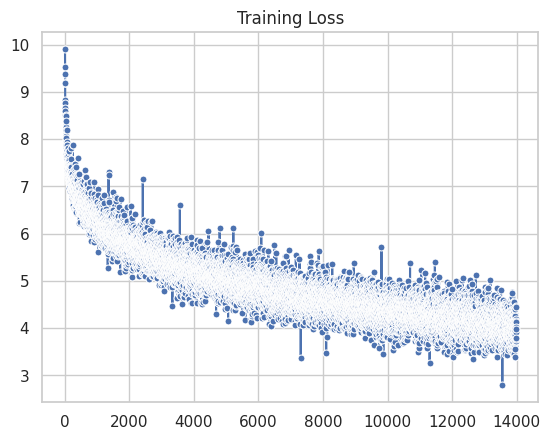

In [ ]:
# Plot loss
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.lineplot(x=range(len(train_losses)), y=train_losses, marker='o', markersize=5)
plt.title("Training Loss")

### Generate Some Examples

Generate using greedy decoding. You will learn more about it in class later in the semester.

You can either use the model you trained, or a model we provide hosted on HuggingFace [here](https://huggingface.co/bkhmsi/epfl-cs552-translation-fr-en) for prediction and attention weight visualization.

The model was trained using the following configuration
```
{
    "src_vocab_size": 32000,
    "tgt_vocab_size": 32000,
    "max_seq_len": 512,
    "num_heads": 8,
    "num_layers": 8,
    "hidden_dim": 1024,
    "intermediate_size": 2048
    "epochs": 20,
    "batch_size": 64
    "learning_rate": 1e-4
}
```

In [ ]:
# Load the model we provide

import os
import json
from huggingface_hub import hf_hub_download

hf_model_path = hf_hub_download(
    repo_id="bkhmsi/epfl-cs552-translation-fr-en",
    filename="pytorch_model.bin"
)

state_dict = torch.load(hf_model_path, map_location="cpu")

config = {
    "src_vocab_size": 32000,
    "tgt_vocab_size": 32000,
    "num_heads": 8,
    "num_layers": 8,
    "hidden_dim": 1024,
    "intermediate_size": 2048
}

num_heads = config["num_heads"]

model = Transformer(**config)
model.load_state_dict(state_dict)
model.to(device)
model.eval()

hf_tokenizer_path = hf_hub_download(
    repo_id="bkhmsi/epfl-cs552-translation-fr-en",
    filename="tokenizer.json",
)

hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=hf_tokenizer_path,
    bos_token="<s>",
    eos_token="</s>",
    unk_token="<unk>",
    pad_token="<pad>",
)

In [ ]:
# or load the model you trained

model = Transformer(
    src_vocab_size=hf_tokenizer.vocab_size,
    tgt_vocab_size=hf_tokenizer.vocab_size,
    num_layers=num_layers,
    hidden_dim=hidden_dim,
    num_heads=num_heads,
    intermediate_size=intermediate_size
)
model.to(device)

state_dict = torch.load("transformer_model.pt")
print(state_dict.keys())
model.load_state_dict(state_dict)
model.eval()

In [27]:
src_val = [dataset['train'][i]['translation']['fr'] for i in range(5)]
tgt_val = [dataset['train'][i]['translation']['en'] for i in range(5)]

max_len = 512
src_tokens_val = hf_tokenizer(src_val, return_tensors='pt', padding=True, truncation=True, max_length=max_len).to(device)

model.eval()
with torch.no_grad():
    for i in range(5):
        # Prepare inputs
        src = src_tokens_val['input_ids'][i].unsqueeze(0).to(device)
        tgt = torch.tensor([[hf_tokenizer.bos_token_id]], dtype=torch.long, device=device)

        # Greedy decode up to max_len
        for step in range(max_len):
            # Create tgt padding mask
            tgt_mask = torch.ones_like(tgt).bool().to(device)

            # Forward pass
            logits, _ = model(src, tgt, tgt_mask=tgt_mask)

            # Get the most probable token at the current step
            next_token = logits[:, -1, :].argmax(dim=-1)

            # Append
            tgt = torch.cat([tgt, next_token.unsqueeze(-1)], dim=1)

            # End conditions
            if next_token.item() in [hf_tokenizer.eos_token_id, hf_tokenizer.pad_token_id]:
                break

        # Decode
        translation = hf_tokenizer.decode(tgt[0], skip_special_tokens=True)

        print(f"Example {i+1}:")
        print(f"  Source:      {src_val[i]}")
        print(f"  Translation: {translation}")
        print(f"  Target:      {tgt_val[i]}\n")

Example 1:
  Source:      À mesure que Maurice devient une économie à forte intensité de savoir, que le secteur des technologies de l'information et de la communication (TIC) se développe avec l'idée de faire de Maurice une cyber-île, l'écart actuel des connaissances risque fort de se creuser, surtout chez les femmes, sauf si les réformes de l'enseignement sont adaptées aux impératifs neufs du marché du travail.
  Translation: As Mauritius becomes a real world waresia, information and communication technologies are prepared to ensure that, above all, the mainland shows are different in terms of the labour sector's success. This applies to more recent years than the actual figures concub was similar to those, especially in terms of the labour market. This activities include new exigencies (Table 4) and agreed to complement the existing knowledge. which are different when added. affair's ones being achieved (10) make to the contribution towards the transition to the real GDP of the resea

## Analyze Cross-Attention Weights

- Choose one sample sentence, output attention weights for each token using heatmap
- Which pairs of the token have the greatest attention weight?

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_cross_attention(
    attn_weights,
    source_tokens,
    target_tokens,
    batch_idx=0,
    head_idx=0,
    title="Cross-Attention"
):
    """
    Visualize cross-attention weights for a given batch and head.

    Args:
        attn_weights: Tensor of shape [batch_size, num_heads, tgt_len, src_len]
            Cross-attention weights from your Transformer decoder,
            typically returned alongside logits in a (logits, attn_weights) tuple.
        source_tokens: List of source tokens (strings) for the batch_idx sample.
        target_tokens: List of target tokens (strings) for the batch_idx sample.
        batch_idx: Which batch element to visualize (default=0).
        head_idx: Which attention head to visualize (default=0).
        title: Title for the plot.

    Example Usage:
        # Suppose attn_weights has shape [batch_size, num_heads, tgt_len, src_len]
        # and you have the corresponding token lists for the source and target:
        visualize_cross_attention(attn_weights, src_tokens, tgt_tokens)
    """

    # 1) Extract the attention for the specified batch & head
    #    shape: [tgt_len, src_len]
    attn = attn_weights[batch_idx, head_idx].detach().cpu().numpy()

    tgt_len, src_len = attn.shape

    # 2) Plot the heatmap
    plt.figure(figsize=(min(12, 1 + 0.5 * src_len), min(6, 1 + 0.5 * tgt_len)))
    sns.heatmap(attn,
                vmin=0.0, vmax=1.0,
                cmap="Blues",
                xticklabels=source_tokens,
                yticklabels=target_tokens,
                cbar=True)

    plt.title(f"{title} (batch={batch_idx}, head={head_idx})")
    plt.xlabel("Source Tokens")
    plt.ylabel("Target Tokens")

    # Rotate the x-axis labels if tokens are long
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


En intégrant à ces modèles diverses hypothèses issues des sources écrites en la matière, il a pu faire des estimations concernant l’exposition au virus de la grippe et le risque d’infection.
By plugging various assumptions derived from the literature into these models he made estimates of exposure to and risk of influenza infection.
torch.Size([1, 37])
torch.Size([1, 24])


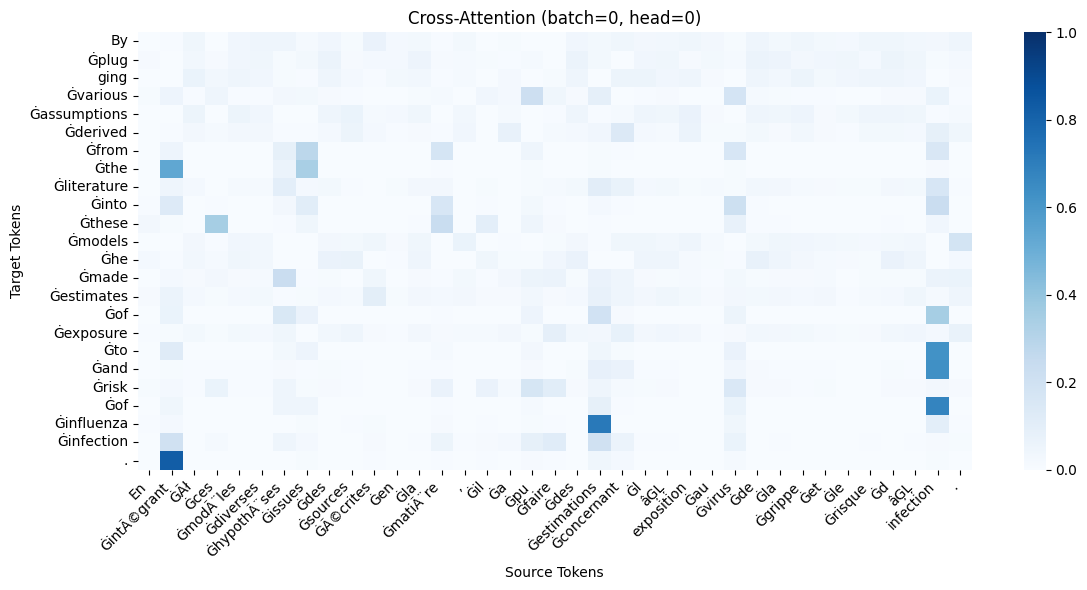

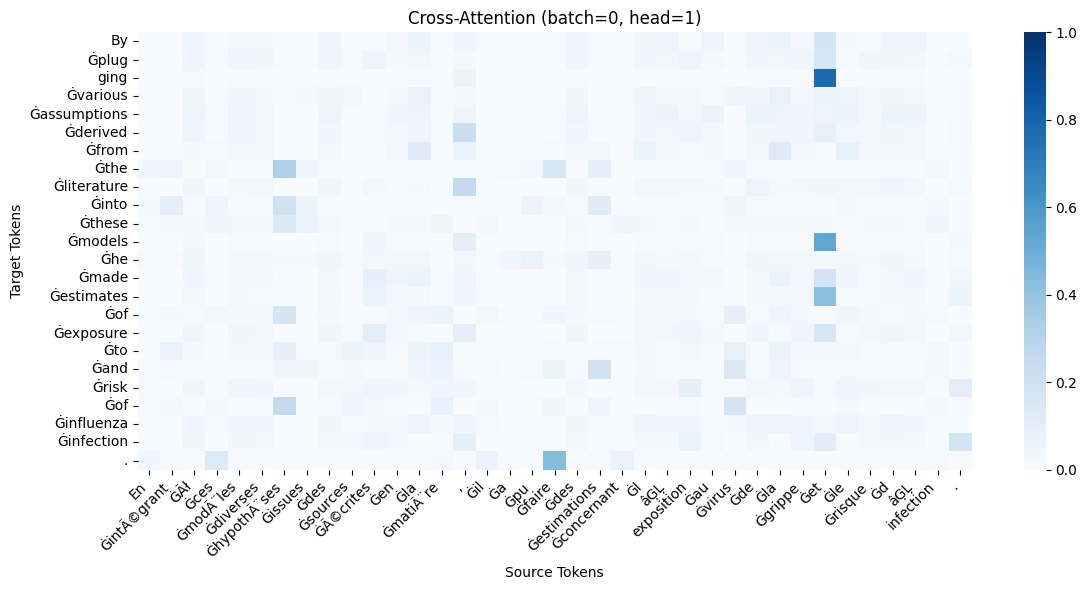

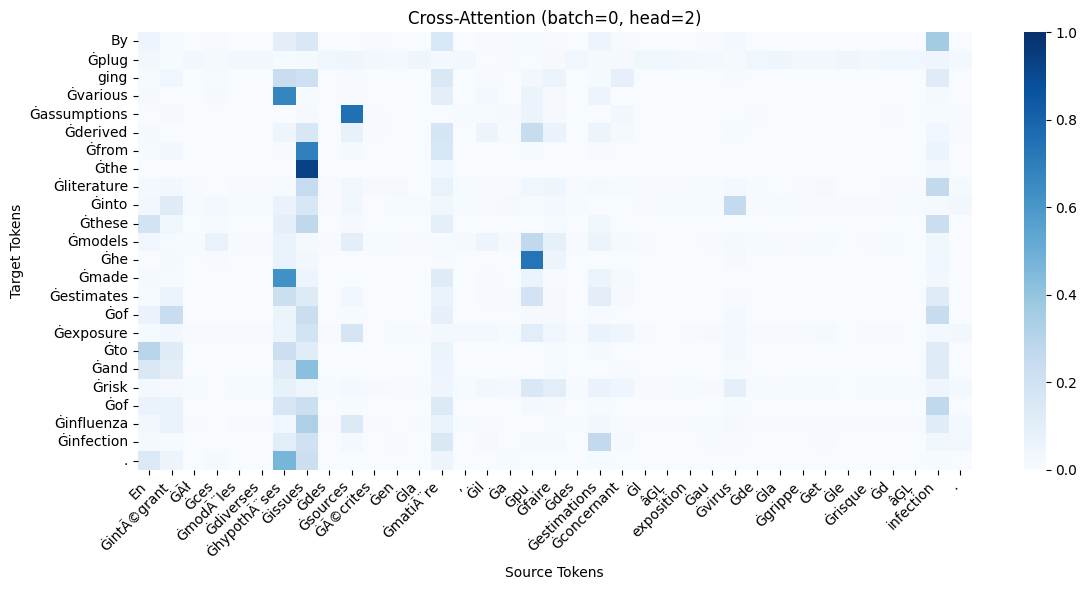

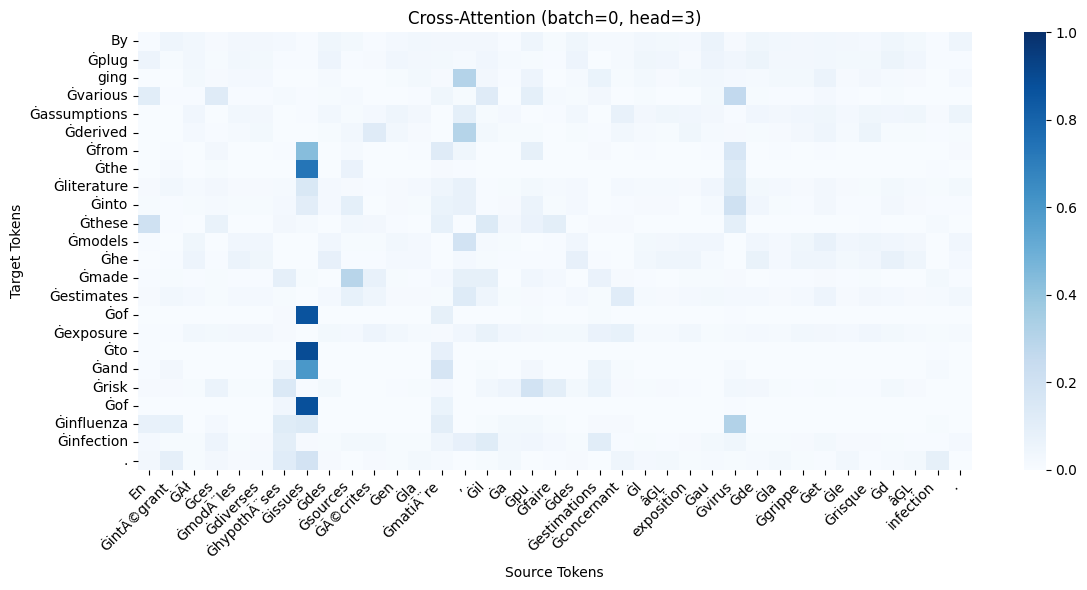

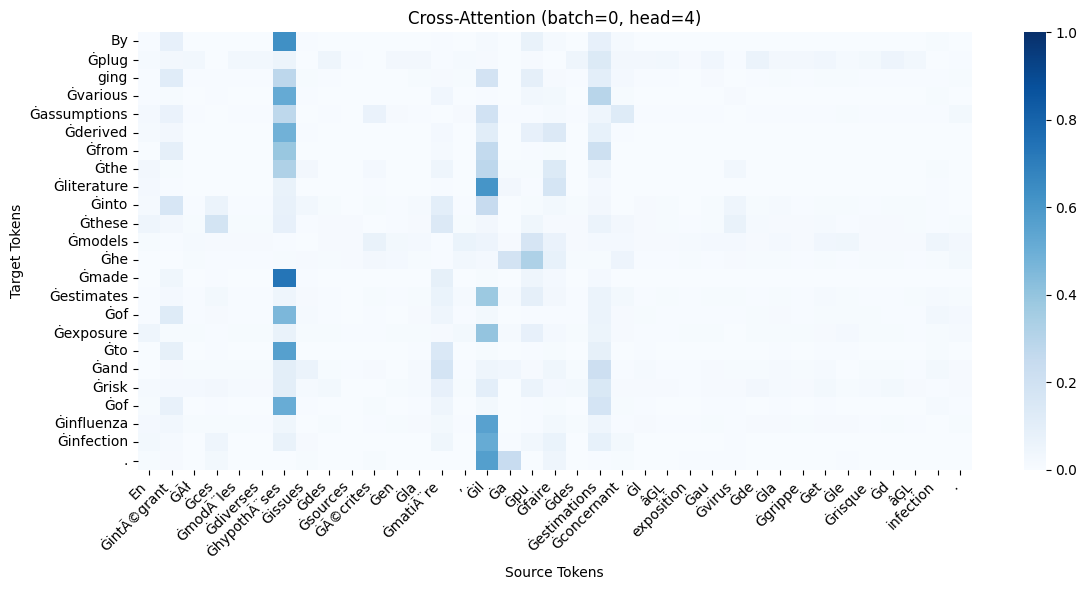

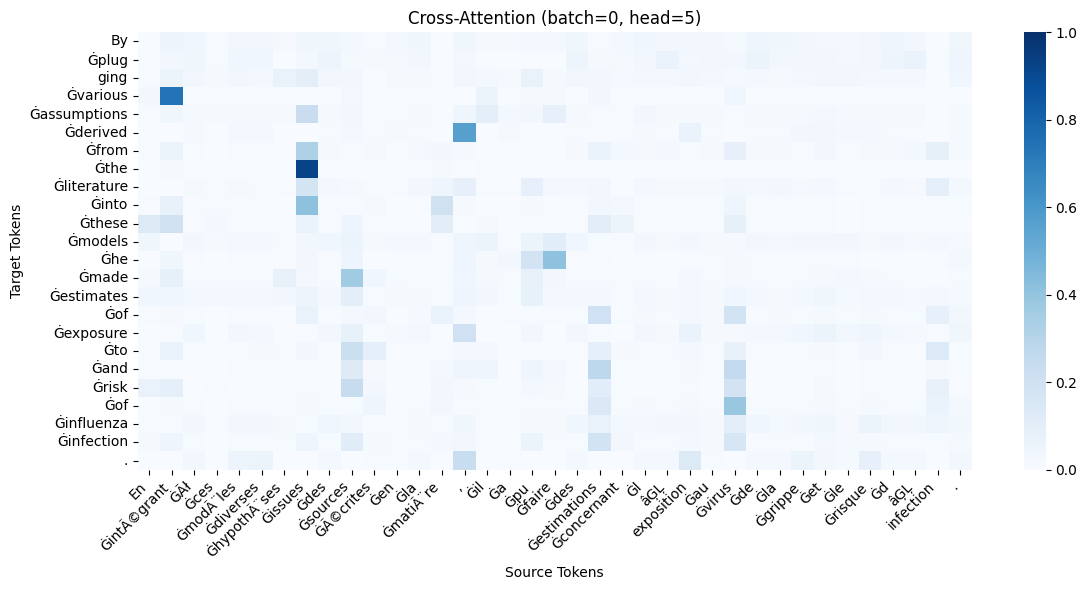

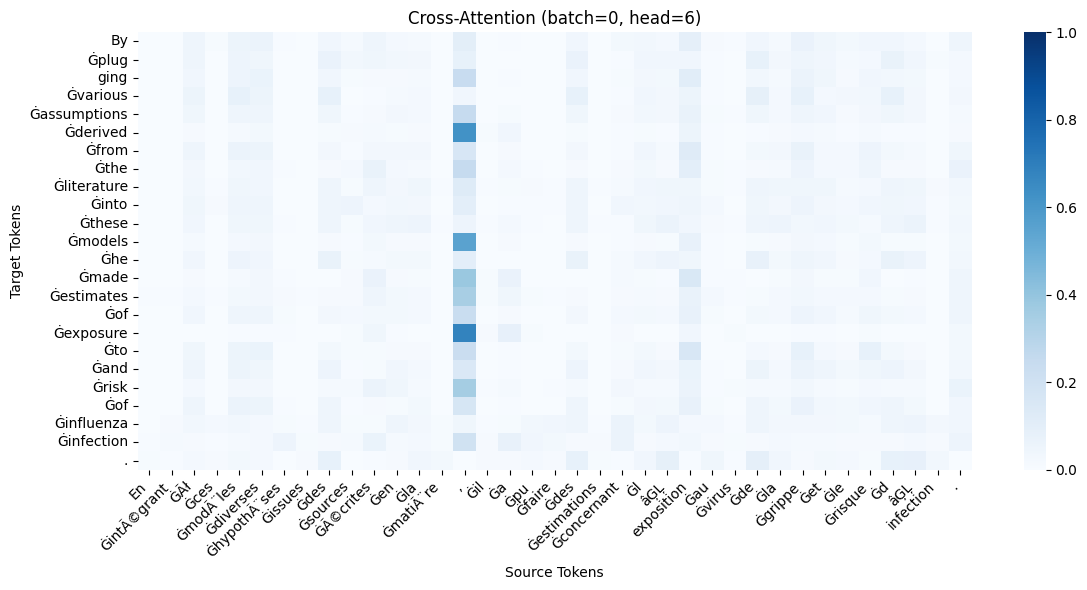

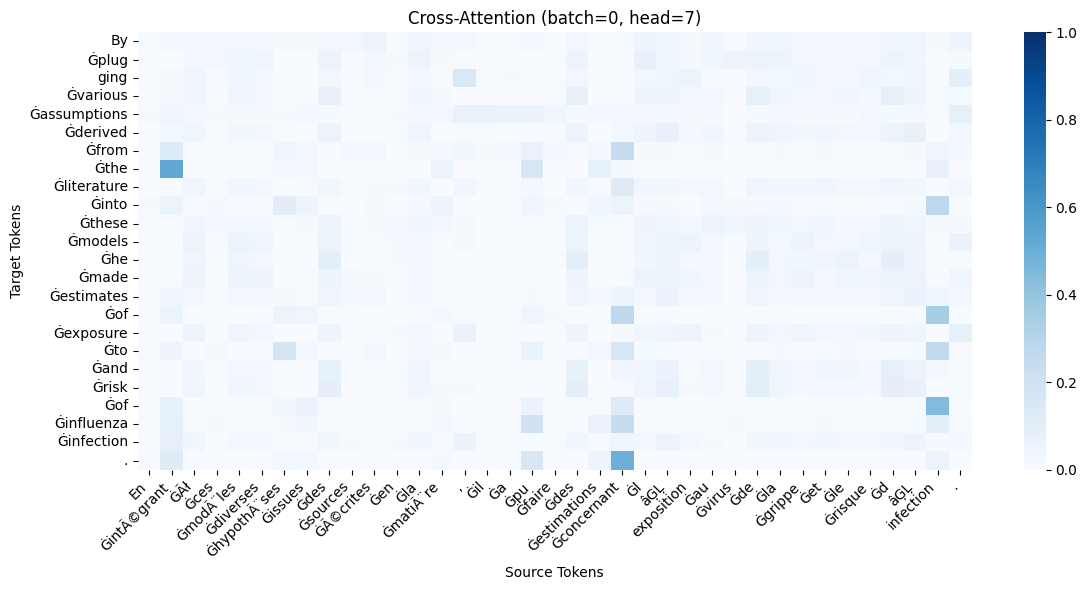

In [33]:
idx = 1
src_val = dataset['train'][idx]['translation']['fr']
tgt_val = dataset['train'][idx]['translation']['en']

print(src_val)
print(tgt_val)

# Tokenize the source and target
src_tokens_val = hf_tokenizer(
    src_val,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=max_len
).to(device)
tgt_tokens_val = hf_tokenizer(
    tgt_val,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=max_len
).to(device)

print(src_tokens_val["input_ids"].shape)
print(tgt_tokens_val["input_ids"].shape)

# Run the model
model.eval()
with torch.no_grad():
    logits, attn_weights = model(
        src=src_tokens_val['input_ids'],
        tgt=tgt_tokens_val['input_ids'],
        src_mask=src_tokens_val['attention_mask'],
        tgt_mask=tgt_tokens_val['attention_mask']
    )

# Convert IDs back to token strings for axis labels
src_tokens = hf_tokenizer.convert_ids_to_tokens(src_tokens_val["input_ids"][0])
tgt_tokens = hf_tokenizer.convert_ids_to_tokens(tgt_tokens_val["input_ids"][0])

# Visualize the attention weights
for i in range(num_heads):
    visualize_cross_attention(
        attn_weights=attn_weights,
        source_tokens=src_tokens,
        target_tokens=tgt_tokens,
        batch_idx=0,
        head_idx=i
    )


## Congrats! You can now train a simple machine translator by your own ;)